<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# **BOW y MLP**

Importamos lo necesario

In [ ]:
import os
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    Input,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

Configuración general


MODE controla el encoding del Bag of Words:
* "binary": multi-hot: 1 si la palabra aparece en el review, 0 si no. Es el estandar para IMDB + MLP; ignora la frecuencia, que en textos cortos aporta poco y hace que reviews largos tengan activaciones mucho mas grandes.
* "count_norm": conteos divididos por la cantidad total de tokens del review. Conserva la frecuencia relativa sin que la longitud del texto infle la magnitud del vector de entrada.
* "compare": entrena los dos y compara los resultados.

In [ ]:
MODE = "compare"

VOCAB_SIZE = 5000  # nos quedamos con las 5000 palabras mas frecuentes
SEED = 42  # semilla unica para todas las fuentes de aleatoriedad
EPOCHS = 20  # el early stopping suele cortar antes
BATCH_SIZE = 32
LEARNING_RATE = 1e-4 # lr bajo: el modelo sobreajusta rapido con BoW

Indices reservados por keras.datasets.imdb (parametro index_from=3):
* 0: padding
* 1: start of sequence (keras lo antepone a todos los reviews)
* 2: out of vocabulary (palabra fuera de las num_words mas frecuentes)


Por eso los indices de word_index hay que desplazarlos +3 para que coincidan con los indices que aparecen en X_train / X_test.

In [ ]:
START_IDX, OOV_IDX, INDEX_FROM = 1, 2, 3

Fijamos las semillas para que el experimento sea reproducible

In [ ]:
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Comprobamos la GPU

In [ ]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Cargamos el dataset de IMDB

In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (25000,)
Test shape: (25000,)


Convertimos las secuencias a Bag of Words


Esta función convierte una lista de secuencias de indices en una matriz Bag of Words. El BoW descarta el orden de las palabras: cada review pasa a ser un vector de largo donde la posicion i representa a la palabra i.

In [ ]:
def sequences_to_bow(sequences, dimension, mode):
    results = np.zeros((len(sequences), dimension), dtype="float32")

    # Contamos las apariciones de cada indice
    for i, sequence in enumerate(sequences):
        for word_idx in sequence:
            results[i, word_idx] += 1.0

    if mode == "binary":
        # cualquier conteo > 0 pasa a valer 1.
        return (results > 0).astype("float32")

    # count_norm: dividimos cada fila por su total de tokens, de modo que un
    # review de 500 palabras y uno de 50 esten en la misma escala.
    totals = results.sum(axis=1, keepdims=True)
    totals[totals == 0] = 1.0  # evita la division por cero en reviews vacios
    return results / totals

Entrenamos y evaluamos un modelo por cada encoding

In [ ]:
modes = ["binary", "count_norm"] if MODE == "compare" else [MODE]

In [ ]:
results = []  # guardamos modelo, historial y metricas de cada corrida

In [ ]:
for mode in modes:
    print("_"*30)
    print("MODE", mode)

    # Vectorizacion
    X_train_bow = sequences_to_bow(X_train, VOCAB_SIZE, mode)
    X_test_bow = sequences_to_bow(X_test, VOCAB_SIZE, mode)

    # Arquitectura
    # MLP de tres bloques: Dense(relu), BatchNorm, Dropout
    input_layer = Input(shape=(VOCAB_SIZE,))

    x = input_layer
    for units in (512, 256, 128):
        x = Dense(units, activation="relu", kernel_regularizer=l2(1e-4))(x)
        x = BatchNormalization()(x) # estabiliza y acelera la convergencia
        x = Dropout(0.5)(x) # apaga la mitad de las neuronas en train

    output_layer = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    # binary_crossentropy es la loss que corresponde a una salida sigmoid binaria.
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    # Callbacks
    # Cortamos cuando la val_loss deja de mejorar y recuperamos los pesos de la
    # mejor epoca
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    )

    # Entrenamiento
    history = model.fit(
        X_train_bow,
        y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=2,
    )

    # Evaluacion
    loss, accuracy = model.evaluate(X_test_bow, y_test, verbose=0)

    # predict devuelve probabilidades; umbral 0.5 para pasarlas a clases.
    y_pred = (model.predict(X_test_bow, verbose=0).ravel() >= 0.5).astype("int32")

    print(f"\nTest loss: {loss:.4f}")
    print(f"Test accuracy: {accuracy:.4f}\n")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["negativo", "positivo"],
            digits=4,
        )
    )
    print("Matriz de confusion:")
    print(confusion_matrix(y_test, y_pred))

    results.append(
        {
            "mode": mode,
            "model": model,
            "history": history.history,
            "loss": loss,
            "accuracy": accuracy,
        }
    )


______________________________
MODE binary
Epoch 1/20
625/625 - 18s - 29ms/step - accuracy: 0.6139 - loss: 0.9447 - val_accuracy: 0.8244 - val_loss: 0.5447
Epoch 2/20
625/625 - 13s - 21ms/step - accuracy: 0.7728 - loss: 0.6420 - val_accuracy: 0.8614 - val_loss: 0.4656
Epoch 3/20
625/625 - 3s - 4ms/step - accuracy: 0.8386 - loss: 0.5203 - val_accuracy: 0.8754 - val_loss: 0.4384
Epoch 4/20
625/625 - 3s - 4ms/step - accuracy: 0.8717 - loss: 0.4531 - val_accuracy: 0.8808 - val_loss: 0.4318
Epoch 5/20
625/625 - 3s - 4ms/step - accuracy: 0.8939 - loss: 0.3996 - val_accuracy: 0.8832 - val_loss: 0.4321
Epoch 6/20
625/625 - 4s - 6ms/step - accuracy: 0.9146 - loss: 0.3507 - val_accuracy: 0.8840 - val_loss: 0.4393
Epoch 7/20
625/625 - 4s - 6ms/step - accuracy: 0.9283 - loss: 0.3169 - val_accuracy: 0.8828 - val_loss: 0.4475

Test loss: 0.4367
Test accuracy: 0.8761

              precision    recall  f1-score   support

    negativo     0.8668    0.8887    0.8776     12500
    positivo     0.8858  

Comparamos los resultados

In [ ]:
for r in results:
    print(f"{r['mode']:<12} test_acc={r['accuracy']:.4f}  test_loss={r['loss']:.4f}")

binary       test_acc=0.8761  test_loss=0.4367
count_norm   test_acc=0.8811  test_loss=0.4101


El modelo ganador es el que usamos despues para la inferencia

In [ ]:
best = max(results, key=lambda r: r["accuracy"])
print("\nMejor encoding:", best["mode"])


Mejor encoding: count_norm


Graficamos el accuracy

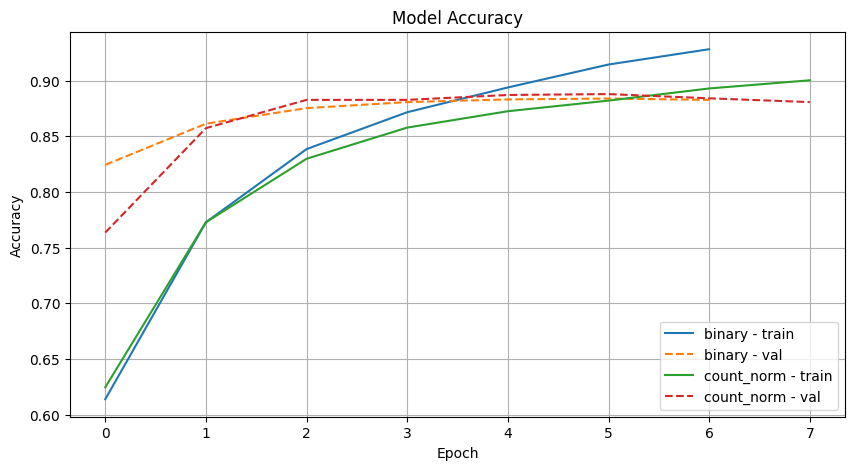

In [ ]:
plt.figure(figsize=(10, 5))
for r in results:
    plt.plot(r["history"]["accuracy"], label=f"{r['mode']} - train")
    plt.plot(r["history"]["val_accuracy"], linestyle="--", label=f"{r['mode']} - val")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Graficamos el loss

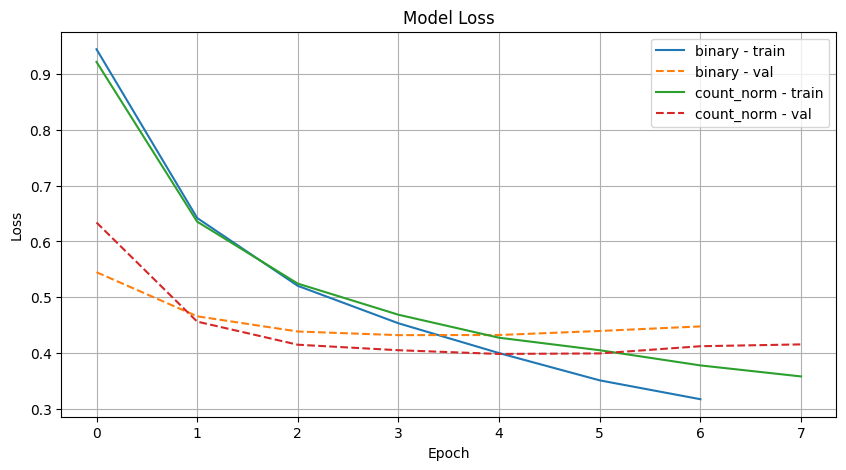

In [ ]:
plt.figure(figsize=(10, 5))
for r in results:
    plt.plot(r["history"]["loss"], label=f"{r['mode']} - train")
    plt.plot(r["history"]["val_loss"], linestyle="--", label=f"{r['mode']} - val")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Inferencia**

El texto nuevo tiene que atravesar exactamente el
mismo preprocesamiento que keras le aplico al dataset. Cualquier diferencia
significa evaluar el modelo sobre una distribucion de entrada distinta de la
que vio en entrenamiento.

word_index mapea palabra a ranking de frecuencia (1 = la mas frecuente)

In [ ]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Tokenizador

In [ ]:
TOKEN_RE = re.compile(r"[a-z']+")

Convierte texto crudo en el mismo vector BoW que produce el pipeline de train

In [ ]:
def encode_text_bow(text, mode, dimension=VOCAB_SIZE):

    vector = np.zeros(dimension, dtype="float32")

    # keras antepone el start token a cada review del dataset, asi que la
    # posicion 1 esta activa en todas las filas de entrenamiento
    vector[START_IDX] = 1.0

    for word in TOKEN_RE.findall(text.lower()):
        idx = word_index.get(word)

        if idx is None:
            # Palabra que ni siquiera figura en el vocabulario de IMDB.
            idx = OOV_IDX
        else:
            idx += INDEX_FROM  # alineamos con los indices del dataset
            if idx >= dimension:
                # Palabra conocida pero fuera de las num_words mas frecuentes:
                # en entrenamiento keras la reemplazo por OOV, hacemos lo mismo.
                idx = OOV_IDX

        vector[idx] += 1.0

    # Aplicamos la misma transformacion final que sequences_to_bow.
    if mode == "binary":
        vector = (vector > 0).astype("float32")
    else:
        total = vector.sum()
        if total > 0:
            vector = vector / total

    # El modelo espera un batch, no un vector suelto: (dimension,) -> (1, dimension).
    return np.expand_dims(vector, axis=0)

Realizamos inferencia en nuevas secuencias

In [ ]:
textos = [
    "This movie was amazing, I loved it!",
    "This film was terrible and boring.",
    "The actors were fantastic and the story was beautiful.",
    "Worst movie ever.",
]

print("\nInferencia (encoding:", best["mode"], ")\n")

for texto in textos:
    encoded = encode_text_bow(texto, best["mode"])

    # predict devuelve shape (1, 1): [0][0] extrae el escalar.
    score = float(best["model"].predict(encoded, verbose=0)[0][0])
    sentimiento = "POSITIVO" if score >= 0.5 else "NEGATIVO"

    print(f"TEXT: {texto}")
    print(f"SCORE: {round(score, 4)}  ->  {sentimiento}")
    print("-" * 60)


Inferencia (encoding: count_norm )

TEXT: This movie was amazing, I loved it!
SCORE: 1.0  ->  POSITIVO
------------------------------------------------------------
TEXT: This film was terrible and boring.
SCORE: 0.0  ->  NEGATIVO
------------------------------------------------------------
TEXT: The actors were fantastic and the story was beautiful.
SCORE: 0.9999  ->  POSITIVO
------------------------------------------------------------
TEXT: Worst movie ever.
SCORE: 0.0  ->  NEGATIVO
------------------------------------------------------------
